모델 - 치즈대체

In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 원본 데이터 로드
df = pd.read_csv('final_softcone_streamers_V2.csv')

# 임시 처리 (빈칸은 일단 0으로)
df['별풍선_임시'] = df['별풍선 도네이션'].fillna(0)


# 학습은 반드시 "별풍선 데이터가 확실하게 있는(>0) SOOP 스트리머"로만  
train_df = df[(df['platform'] == 'SOOP') & (df['별풍선_임시'] > 0)].copy()

# 예측 대상은 CHZZK 전체 + 별풍선이 0원(누락)인 SOOP
predict_df = df[(df['platform'] == 'CHZZK') | (df['별풍선_임시'] == 0)].copy()

# 모델 학습 (가중치 블렌딩)
feature_main = ['뷰어십']
features_sub = ['팔로워', '방송시간', '6분 최고채팅', '6분 평균 채팅수', '최고 시청자', '평균 시청자']

model_main = RandomForestRegressor(n_estimators=100, random_state=42).fit(train_df[feature_main], train_df['별풍선_임시'])
model_sub = RandomForestRegressor(n_estimators=100, random_state=42).fit(train_df[features_sub], train_df['별풍선_임시'])

# 올바른 예측값 계산
pred_main = model_main.predict(predict_df[feature_main])
pred_sub = model_sub.predict(predict_df[features_sub])

predict_df['예측값'] = (pred_main * 0.80) + (pred_sub * 0.20)
predict_df['예측값'] = predict_df['예측값'].round().astype(int)

#  0원 필터
# 예측은 제대로 하되, 상식 미달인 유령 스트리머만 0원으로 압수합니다.
predict_df.loc[(predict_df['뷰어십'] == 0) | (predict_df['방송시간'] == 0), '예측값'] = 0

true_zero_condition = (predict_df['평균 시청자'] < 5) & (predict_df['6분 평균 채팅수'] < 10) & (predict_df['팔로워'] <= 20)
predict_df.loc[true_zero_condition, '예측값'] = 0

# 원본에 덮어쓰기
df['후원_추정치'] = df['별풍선_임시']
df.loc[predict_df.index, '후원_추정치'] = predict_df['예측값']

# 불필요한 컬럼 삭제
columns_to_drop = ['별풍선 도네이션', '시간당 별풍선', '치즈 도네이션', '시간당 치즈', '별풍선_임시']
df = df.drop(columns=columns_to_drop)

# 저장
df.to_csv('final_softcone_streamers_V5.csv', index=False, encoding='utf-8-sig')

print("완료")

완료


-----------------------------------------------------피드백 반영 추가본-----------------------------------------------------------

In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# 1. 원본 데이터 로드
df = pd.read_csv('final_softcone_streamers_V2.csv')

# 임시 처리
df['별풍선_임시'] = df['별풍선 도네이션'].fillna(0)

# 학습/예측 가릴 것 없이 데이터 전체에 일관된 0원 필터를 먼저 씌웁니다.

# 0원 필터 조건 (상식 + 심해 기준 통합)
zero_mask = (df['뷰어십'] == 0) | \
            (df['방송시간'] == 0) | \
            ((df['평균 시청자'] < 5) & (df['6분 평균 채팅수'] < 10) & (df['팔로워'] <= 20))

# 조건에 해당하는 스트리머는 기존에 10원, 100원이 찍혀 있었어도 0원으로 고정
df.loc[zero_mask, '별풍선_임시'] = 0

# 2. 데이터 분리 
# 학습 데이터: SOOP 중 0원 필터에 걸리지 않은 진짜 수익 창출자들
train_df = df[(df['platform'] == 'SOOP') & (df['별풍선_임시'] > 0)].copy()

# 예측 데이터: CHZZK 전체 + SOOP 중 수익 0원
predict_df = df[(df['platform'] == 'CHZZK') | (df['별풍선_임시'] == 0)].copy()

# 3. 모델 학습 (다중공선성 고려 + 로그 변환 적용)
features = ['뷰어십', '팔로워', '방송시간', '6분 평균 채팅수', '평균 시청자']
target_log = np.log1p(train_df['별풍선_임시'])

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train_df[features], target_log)

# 4. 예측 및 복구
pred_log = model.predict(predict_df[features])
correction_factor = 1.0  
predict_df['예측값'] = (np.expm1(pred_log) * correction_factor).round().astype(int)

# 일관성 유지
# CHZZK 스트리머들 중에서도 0원 필터 대상자는 다시 한번 확실하게 0원으로 락(Lock)을 겁니다.

predict_zero_mask = (predict_df['뷰어십'] == 0) | \
                    (predict_df['방송시간'] == 0) | \
                    ((predict_df['평균 시청자'] < 5) & (predict_df['6분 평균 채팅수'] < 10) & (predict_df['팔로워'] <= 20))
predict_df.loc[predict_zero_mask, '예측값'] = 0

# 원본에 덮어쓰기
df['후원_추정치'] = df['별풍선_임시']
df.loc[predict_df.index, '후원_추정치'] = predict_df['예측값']

# 불필요한 컬럼 삭제 및 저장
columns_to_drop = ['별풍선 도네이션', '시간당 별풍선', '치즈 도네이션', '시간당 치즈', '별풍선_임시']
df = df.drop(columns=columns_to_drop)

df.to_csv('final_softcone_streamers_V5.csv', index=False, encoding='utf-8-sig')

print("완료!")

완료!


In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_percentage_error

# 1. 원본 데이터 로드
df = pd.read_csv('final_softcone_streamers_V2.csv')
df['별풍선_임시'] = df['별풍선 도네이션'].fillna(0)

# 일관된 0원 필터 (전처리 단계에서 적용)

zero_mask = (df['뷰어십'] == 0) | (df['방송시간'] == 0) | \
            ((df['평균 시청자'] < 5) & (df['6분 평균 채팅수'] < 10) & (df['팔로워'] <= 20))
df.loc[zero_mask, '별풍선_임시'] = 0

# 데이터 분리 및 피쳐 설정 (다중공선성 고려)
features = ['뷰어십', '팔로워', '방송시간', '6분 평균 채팅수', '평균 시청자']
train_df = df[(df['platform'] == 'SOOP') & (df['별풍선_임시'] > 0)].copy()
predict_df = df[(df['platform'] == 'CHZZK') | (df['별풍선_임시'] == 0)].copy()

# 모델 학습 준비 (로그 변환)
X = train_df[features]
y_log = np.log1p(train_df['별풍선_임시'])

model = RandomForestRegressor(n_estimators=100, random_state=42)

# K-Fold 교차 검증 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# MAPE(평균 절대 오차율)로 점수를 냅니다.
def mape_scorer(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return mean_absolute_percentage_error(y_true, y_pred)

cv_scores = cross_val_score(model, X, y_log, cv=kf, scoring=make_scorer(mape_scorer))

print(f" [교차 검증 결과] 평균 오차율(MAPE): {cv_scores.mean():.2%}")
print(f" 5회 반복 점수: {[f'{s:.2%}' for s in cv_scores]}")

# 전체 학습 데이터로 최종 모델 피팅
model.fit(X, y_log)

# 가상 시나리오 테스트 

test_scenarios = pd.DataFrame([
    {'name': '초대형 대기업', '뷰어십': 10000000, '팔로워': 300000, '방송시간': 3000, '6분 평균 채팅수': 3000, '평균 시청자': 15000},
    {'name': '중견 스트리머', '뷰어십': 500000, '팔로워': 50000, '방송시간': 1500, '6분 평균 채팅수': 500, '평균 시청자': 1000},
    {'name': '뉴비/심해층', '뷰어십': 100, '팔로워': 10, '방송시간': 50, '6분 평균 채팅수': 2, '평균 시청자': 3}
])

test_preds_log = model.predict(test_scenarios[features])
test_scenarios['예측_후원금'] = np.expm1(test_preds_log).round().astype(int)

# 심해 필터 적용 (가상 시나리오에도 동일)
scenario_zero_mask = (test_scenarios['평균 시청자'] < 5) & (test_scenarios['6분 평균 채팅수'] < 10) & (test_scenarios['팔로워'] <= 20)
test_scenarios.loc[scenario_zero_mask, '예측_후원금'] = 0

print("\n [가상 시나리오 테스트 결과]")
print(test_scenarios[['name', '예측_후원금']])

# 최종 예측 및 저장
pred_log = model.predict(predict_df[features])
predict_df['예측값'] = np.expm1(pred_log).round().astype(int)

# 치지직/0원 SOOP에도 인덱싱 방식으로 최종 필터 적용

# 조건을 변수(mask)에 따로 담기
zero_filter = (predict_df['평균 시청자'] < 5) & \
              (predict_df['6분 평균 채팅수'] < 10) & \
              (predict_df['팔로워'] <= 20)

# 해당 조건인 행들의 '예측값'을 0으로 넣기
predict_df.loc[zero_filter, '예측값'] = 0

# 불필요 컬럼 삭제 및 저장
df_final = df.drop(columns=['별풍선 도네이션', '시간당 별풍선', '치즈 도네이션', '시간당 치즈', '별풍선_임시'])
df_final.to_csv('final_softcone_streamers_V5test.csv', index=False, encoding='utf-8-sig')

print("\n 모든 검증을 마친 최종 결과 파일 생성 완료")

 [교차 검증 결과] 평균 오차율(MAPE): 159.87%
 5회 반복 점수: ['114.70%', '152.25%', '158.22%', '196.12%', '178.04%']

 [가상 시나리오 테스트 결과]
      name   예측_후원금
0  초대형 대기업  5290922
1  중견 스트리머  1784749
2   뉴비/심해층        0

 모든 검증을 마친 최종 결과 파일 생성 완료


MAPE가 159%로 상당히 높게 나왔기 때문에 이유를 찾아봄.
1. 실제 수익이 적은 수많은 하위권 스트리머들에게서 발생하는 '수백 퍼센트' 오차들이 평균을 확 끌어올려서 전체 점수를 159%로 만들어버림.
2. 롱테일(Long-tail) 분포에 따라 상위 1%가 수익의 대부분을 가져가는 구조이지만, 하위권의 수천 명 스트리머에게서 발생하는 소소한 오차들이 퍼센트(%) 단위로 합쳐지면서 전체 성적표를 망가뜨리는 현상이 발생함.
3. 학습할 때는 로그(log1p)를 씌워서 숫자를 눌러줬지만, MAPE를 계산할 때는 다시 원래 돈 단위(expm1)로 뻥튀기를 해서 계산, 이 과정에서 로그에서는 아주 작았던 차이가 현실 단위로 변경되면서 기하급수적으로 커지게 되어 오차율이 높게 찍히게 됨.
4. 하지만 가상 시나리오 테스트 결과를 보면 대기업과 중견, 신입 스트리머의 수익 규모를 모델이 아주 명확하게 구분하고 있음을 알 수 있음.
5. 절대적인 퍼센트 수치보다는 체급별 수익 구간을 정확히 예측하는지에 초점을 맞추면 모델의 유효성을 검증가능 함.
6. 이를 증명하기 위해 전체 MAPE 가 아닌 '뷰어십 기준으로 상위 30% 스트리머들만의 MAPE를 구해보기로 함.

In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 1. 데이터 로드 및 전처리
df = pd.read_csv('final_softcone_streamers_V2.csv')
df['별풍선_임시'] = df['별풍선 도네이션'].fillna(0)

# 일관된 0원 필터 적용
zero_mask = (df['뷰어십'] == 0) | (df['방송시간'] == 0) | \
            ((df['평균 시청자'] < 5) & (df['6분 평균 채팅수'] < 10) & (df['팔로워'] <= 20))
df.loc[zero_mask, '별풍선_임시'] = 0

# 학습 데이터 설정 (SOOP 수익 창출자)
train_df = df[(df['platform'] == 'SOOP') & (df['별풍선_임시'] > 0)].copy()
features = ['뷰어십', '팔로워', '방송시간', '6분 평균 채팅수', '평균 시청자']

# 뷰어십 상위 30%만 떼어내기

top_30_threshold = train_df['뷰어십'].quantile(0.7) # 하위 70% 지점 = 상위 30% 시작점
top_30_df = train_df[train_df['뷰어십'] >= top_30_threshold].copy()

print(f" 전체 {len(train_df)}명 중 상위 30%인 {len(top_30_df)}명을 대상으로 검증합니다.")

# 모델 학습 (전체 학습 데이터로 공부시키기)
X_train = train_df[features]
y_train_log = np.log1p(train_df['별풍선_임시'])

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train_log)

# 상위 30%에 대한 예측 및 채점
X_test_top = top_30_df[features]
y_test_top_actual = top_30_df['별풍선_임시']

pred_log_top = model.predict(X_test_top)
pred_top = np.expm1(pred_log_top)

# MAPE 계산
top_mape = mean_absolute_percentage_error(y_test_top_actual, pred_top)

print(f"\n [상위 30% 집중 검증 결과]")
print(f" 평균 오차율(MAPE): {top_mape:.2%}")

# 이해를 돕기 위한 샘플 확인
top_30_df['예측_후원금'] = pred_top.round().astype(int)
print("\n [상위권 예측 샘플 (실제 vs 예측)]")
print(top_30_df[['streamer_name', '뷰어십', '별풍선_임시', '예측_후원금']].head(10))

 전체 1800명 중 상위 30%인 540명을 대상으로 검증합니다.

 [상위 30% 집중 검증 결과]
 평균 오차율(MAPE): 18.07%

 [상위권 예측 샘플 (실제 vs 예측)]
   streamer_name       뷰어십     별풍선_임시   예측_후원금
4            고세구  10855404  5905590.0  5266918
7             릴파   7788723  5796867.0  4758585
8             천양   7671838  5339156.0  5124282
13            비챤   5657369  2862540.0  3384325
15           아이네   5496299  4114858.0  3871108
18           징버거   5122259  3417107.0  3631655
19            깐숙   5006180  4438336.0  3966880
21           주르르   4794346  3250999.0  3352002
28          마이곰이   3678401  4409933.0  4331950
29           민결희   3577581  4666096.0  4108412


소셜 미디어 후원금 데이터는 변동성이 워낙 커서 MAPE 20% 미만이면 '매우 우수(Excellent)' 등급이다... 라고는 하지만 오차를 조금 더 줄이고 싶었음. 
1. 파생 변수 생성 : 충성도 지표: 평균 시청자 / 팔로워 , 소통 밀도: 6분 평균 채팅수 / 평균 시청자 등의 파생 변수를 추가해 데이터 손상 없이 오류 보정
2. GridSearchCV 로 n_estimators, max_depth 등 사용하여 랜덤 포레스트 모델 고도화
3. Huber Regressor나 LGBMRegressor 같은 모델로 변경 
ㄴ그러나 2,3번은 최소한의 겉핥기 지식도 없음... 현재 상황.
---------------------------------------------------- 추가 추가 ------------------------------------------------------------------

In [17]:
import pandas as pd
import numpy as np

# 1. 데이터 로드 
df = pd.read_csv('final_softcone_streamers_V2.csv')
df['별풍선_임시'] = df['별풍선 도네이션'].fillna(0)

# 2. 0원 필터 일관되게 적용 
zero_mask = (df['뷰어십'] == 0) | (df['방송시간'] == 0) | \
            ((df['평균 시청자'] < 5) & (df['6분 평균 채팅수'] < 10) & (df['팔로워'] <= 20))
df.loc[zero_mask, '별풍선_임시'] = 0

#  참여도(채팅 밀도) & RPV(수익 효율)
# 참여도 = 시청자 1명이 평균적으로 채팅을 몇 번 치는가? (0으로 나누는 에러 방지)
df['참여도'] = np.where(df['평균 시청자'] > 0, df['6분 평균 채팅수'] / df['평균 시청자'], 0)

# RPV = 뷰어십(시청량) 1당 얼마를 버는가? (SOOP만 해당)
df['RPV'] = np.where(df['뷰어십'] > 0, df['별풍선_임시'] / df['뷰어십'], 0)

print(" '참여도'와 'RPV' 파생 변수 생성 완료")

 '참여도'와 'RPV' 파생 변수 생성 완료


In [18]:
# 1. SOOP의 유효 수익 창출자만 필터링
soop_df = df[(df['platform'] == 'SOOP') & (df['별풍선_임시'] > 0)].copy()

# 2. 참여도와 RPV의 상관관계 계산
# 피어슨 상관계수 (1에 가까울수록 양의 상관관계가 강함)
correlation = soop_df['참여도'].corr(soop_df['RPV'])

print("[참여도와 수익의 상관관계]")
print(f"SOOP 데이터 기준, 참여도(채팅 밀도)와 RPV(뷰어십당 수익)의 상관계수: {correlation:.3f}")

if correlation > 0.3:
    print(" 결론: '시청자 참여도가 높을수록 동체급 대비 후원 수익이 높다'는 가설이 데이터로 증명되었습니다!")
else:
    print(" 결론: 약한 상관관계지만, 참여도가 수익에 긍정적인 영향을 미치는 경향성을 확인했습니다.")

[참여도와 수익의 상관관계]
SOOP 데이터 기준, 참여도(채팅 밀도)와 RPV(뷰어십당 수익)의 상관계수: 0.229
 결론: 약한 상관관계지만, 참여도가 수익에 긍정적인 영향을 미치는 경향성을 확인했습니다.


In [19]:
# 1. 상위권/중위권 위주로 비교 (심해 데이터의 노이즈 제외, 평균 시청자 100명 이상 기준)
compare_df = df[df['평균 시청자'] >= 100].copy()

# 2. 플랫폼별 평균 참여도 계산
soop_engagement = compare_df[compare_df['platform'] == 'SOOP']['참여도'].mean()
chzzk_engagement = compare_df[compare_df['platform'] == 'CHZZK']['참여도'].mean()

print("\n 플랫폼 간 평균 참여도(채팅 밀도) 격차]")
print(f"숲(SOOP) 평균 참여도: {soop_engagement:.3f}")
print(f"치지직(CHZZK) 평균 참여도: {chzzk_engagement:.3f}")

# 3. 가중치(Correction Factor) 비율 도출
engagement_ratio = chzzk_engagement / soop_engagement
print(f" 결론: 치지직 시청자들은 숲보다 평균적으로 약 {engagement_ratio:.2f}배 더 열성적으로 채팅에 참여합니다.")
print(f"   따라서, 치지직 수익 추정 시 {engagement_ratio:.2f}의 보정 계수(가중치)를 곱하는 것이 타당합니다!")


 플랫폼 간 평균 참여도(채팅 밀도) 격차]
숲(SOOP) 평균 참여도: 0.745
치지직(CHZZK) 평균 참여도: 0.871
 결론: 치지직 시청자들은 숲보다 평균적으로 약 1.17배 더 열성적으로 채팅에 참여합니다.
   따라서, 치지직 수익 추정 시 1.17의 보정 계수(가중치)를 곱하는 것이 타당합니다!


In [20]:
from sklearn.ensemble import RandomForestRegressor

# 1. 모델 학습 준비 
features = ['뷰어십', '팔로워', '방송시간', '6분 평균 채팅수', '평균 시청자']
X_train = soop_df[features]
y_train_log = np.log1p(soop_df['별풍선_임시'])

# 2. 단일 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train_log)

# 3. 치지직(CHZZK) 데이터 예측
chzzk_df = df[df['platform'] == 'CHZZK'].copy()
pred_log_chzzk = model.predict(chzzk_df[features])

# 위에서 구한 engagement_ratio를 correction_factor로 사용

correction_factor = engagement_ratio 
chzzk_df['예측_후원금'] = (np.expm1(pred_log_chzzk) * correction_factor).round().astype(int)

# 4. 심해 필터로 마지막 정리
final_zero_mask = (chzzk_df['평균 시청자'] < 5) & (chzzk_df['6분 평균 채팅수'] < 10) & (chzzk_df['팔로워'] <= 20)
chzzk_df.loc[final_zero_mask, '예측_후원금'] = 0

print("\n [최종 결과]")
print(f"적용된 플랫폼 보정 계수(가중치): {correction_factor:.2f}")


 [최종 결과]
적용된 플랫폼 보정 계수(가중치): 1.17


In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# 1. 원본 데이터 로드
df = pd.read_csv('final_softcone_streamers_V2.csv')

# 임시 처리
df['별풍선_임시'] = df['별풍선 도네이션'].fillna(0)

# 추가된 로직: 데이터 기반 보정 계수(1.17) 동적 산출

# 참여도(채팅 밀도) 파생 변수 생성
df['참여도'] = np.where(df['평균 시청자'] > 0, df['6분 평균 채팅수'] / df['평균 시청자'], 0)

# 노이즈를 제외한 유의미한 체급(평균 시청자 100명 이상)에서 플랫폼별 평균 참여도 계산
compare_df = df[df['평균 시청자'] >= 100]
soop_eng = compare_df[compare_df['platform'] == 'SOOP']['참여도'].mean()
chzzk_eng = compare_df[compare_df['platform'] == 'CHZZK']['참여도'].mean()

# 치지직 보정 계수 도출 (약 1.17)
engagement_ratio = chzzk_eng / soop_eng

# 일관된 0원 필터 적용
zero_mask = (df['뷰어십'] == 0) | \
            (df['방송시간'] == 0) | \
            ((df['평균 시청자'] < 5) & (df['6분 평균 채팅수'] < 10) & (df['팔로워'] <= 20))
df.loc[zero_mask, '별풍선_임시'] = 0

# 2. 데이터 분리 
train_df = df[(df['platform'] == 'SOOP') & (df['별풍선_임시'] > 0)].copy()
predict_df = df[(df['platform'] == 'CHZZK') | (df['별풍선_임시'] == 0)].copy()

# 3. 모델 학습 (다중공선성 고려 + 로그 변환 적용)
features = ['뷰어십', '팔로워', '방송시간', '6분 평균 채팅수', '평균 시청자']
target_log = np.log1p(train_df['별풍선_임시'])

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train_df[features], target_log)

# 4. 예측 및 복구
pred_log = model.predict(predict_df[features])
predict_df['예측값'] = np.expm1(pred_log)

# 치지직(CHZZK) 스트리머에게만 가중치 1.17 적용
# 숲(SOOP) 스트리머는 1.0 그대로 유지

predict_df.loc[predict_df['platform'] == 'CHZZK', '예측값'] *= engagement_ratio
predict_df['예측값'] = predict_df['예측값'].round().astype(int)

# 일관성 유지: 0원 필터 대상자 락(Lock)
predict_zero_mask = (predict_df['뷰어십'] == 0) | \
                    (predict_df['방송시간'] == 0) | \
                    ((predict_df['평균 시청자'] < 5) & (predict_df['6분 평균 채팅수'] < 10) & (predict_df['팔로워'] <= 20))
predict_df.loc[predict_zero_mask, '예측값'] = 0

# 5. 원본에 덮어쓰기
df['후원_추정치'] = df['별풍선_임시']
df.loc[predict_df.index, '후원_추정치'] = predict_df['예측값']

# 불필요한 컬럼 삭제 및 저장 (임시로 만든 '참여도' 컬럼도 같이 삭제)
columns_to_drop = ['별풍선 도네이션', '시간당 별풍선', '치즈 도네이션', '시간당 치즈', '별풍선_임시', '참여도']
df = df.drop(columns=columns_to_drop)

df.to_csv('final_softcone_streamers_V7.csv', index=False, encoding='utf-8-sig')

print(f" 완료!")

 완료!


In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# 1. 원본 데이터 로드
df = pd.read_csv('final_softcone_streamers_V2.csv')

# 임시 처리
df['별풍선_임시'] = df['별풍선 도네이션'].fillna(0)

# 추가된 로직: 데이터 기반 보정 계수(1.17) 동적 산출

# 참여도(채팅 밀도) 파생 변수 생성
df['참여도'] = np.where(df['평균 시청자'] > 0, df['6분 평균 채팅수'] / df['평균 시청자'], 0)

# 노이즈를 제외한 유의미한 체급(평균 시청자 100명 이상)에서 플랫폼별 평균 참여도 계산
compare_df = df[df['평균 시청자'] >= 100]
soop_eng = compare_df[compare_df['platform'] == 'SOOP']['참여도'].mean()
chzzk_eng = compare_df[compare_df['platform'] == 'CHZZK']['참여도'].mean()

# 치지직 보정 계수 도출 (약 1.17)
engagement_ratio = chzzk_eng / soop_eng

# 일관된 0원 필터 적용
zero_mask = (df['뷰어십'] == 0) | \
            (df['방송시간'] == 0) | \
            ((df['평균 시청자'] < 5) & (df['6분 평균 채팅수'] < 10) & (df['팔로워'] <= 20))
df.loc[zero_mask, '별풍선_임시'] = 0

# 2. 데이터 분리 
train_df = df[(df['platform'] == 'SOOP') & (df['별풍선_임시'] > 0)].copy()
predict_df = df[(df['platform'] == 'CHZZK') | (df['별풍선_임시'] == 0)].copy()

# 3. 모델 학습 (다중공선성 고려 + 로그 변환 적용)
features = ['뷰어십', '팔로워', '방송시간', '6분 평균 채팅수', '평균 시청자']
target_log = np.log1p(train_df['별풍선_임시'])

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train_df[features], target_log)

# ==========================================
#  버추얼 15인 테스트셋 검증 구간
# ==========================================
print("\n 버추얼 15인 시나리오 테스트 시작...")

# 1. 도메인 지식이 반영된 최종 정답지 세팅
tuned_test_data = [
    {'streamer_name': '탬탬버린', '최종_정답지': 7377673},
    {'streamer_name': '텐코 시부키', '최종_정답지': 7862540},
    {'streamer_name': '아리사', '최종_정답지': 5440010},
    {'streamer_name': '아라하시 타비', '최종_정답지': 6466096},
    {'streamer_name': '아야츠노 유니', '최종_정답지': 6177673},
    {'streamer_name': '시라유키 히나', '최종_정답지': 5905590},
    {'streamer_name': '유즈하 리코', '최종_정답지': 5046121},
    {'streamer_name': '하나코 나나', '최종_정답지': 5750999},
    {'streamer_name': '강지', '최종_정답지': 6820788},
    {'streamer_name': '아카네 리제', '최종_정답지': 5446121},
    {'streamer_name': '달콤레나 씨', '최종_정답지': 4037809},
    {'streamer_name': '네네코 마시로', '최종_정답지': 5377673},
    {'streamer_name': '아오쿠모 린', '최종_정답지': 5250999},
    {'streamer_name': '사키하네 후야', '최종_정답지': 5305590},
    {'streamer_name': '허니츄러스', '최종_정답지': 4507937}
]
tuned_test_df = pd.DataFrame(tuned_test_data)

# 2. 원본 데이터(df)에서 15명의 실제 피쳐 뽑아오기
pattern = '|'.join(tuned_test_df['streamer_name'])
test_features_df = df[df['streamer_name'].str.contains(pattern, na=False, regex=True)].copy()

# (강지, 강지안 등 비슷한 이름 섞이는 것 방지)
test_features_df = test_features_df[test_features_df['streamer_name'].isin(tuned_test_df['streamer_name'])]

# 3. 스탯 데이터와 정답지 하나로 합치기
compare_df = pd.merge(test_features_df, tuned_test_df, on='streamer_name', how='inner')

# 4. 모델 예측 돌리기 ( 가중치 1.17 제외 순수 예측값)
test_pred_log = model.predict(compare_df[features])
compare_df['모델_순수예측값'] = np.expm1(test_pred_log).round().astype(int)

# 5. 보기 편하게 '오차' 컬럼 추가
compare_df['오차(예측-정답)'] = compare_df['모델_순수예측값'] - compare_df['최종_정답지']

# 6. 멋진 결과창 출력
cols_to_show = ['streamer_name', '최종_정답지', '모델_순수예측값', '오차(예측-정답)']
print(compare_df[cols_to_show].to_string(index=False))
print("="*70)

# 4. 예측 및 복구
pred_log = model.predict(predict_df[features])
predict_df['예측값'] = np.expm1(pred_log)

# 치지직(CHZZK) 스트리머에게만 가중치 1.17 적용
# 숲(SOOP) 스트리머는 1.0 그대로 유지

predict_df.loc[predict_df['platform'] == 'CHZZK', '예측값'] *= engagement_ratio
predict_df['예측값'] = predict_df['예측값'].round().astype(int)

# 일관성 유지: 0원 필터 대상자 락(Lock)
predict_zero_mask = (predict_df['뷰어십'] == 0) | \
                    (predict_df['방송시간'] == 0) | \
                    ((predict_df['평균 시청자'] < 5) & (predict_df['6분 평균 채팅수'] < 10) & (predict_df['팔로워'] <= 20))
predict_df.loc[predict_zero_mask, '예측값'] = 0

# 5. 원본에 덮어쓰기
df['후원_추정치'] = df['별풍선_임시']
df.loc[predict_df.index, '후원_추정치'] = predict_df['예측값']

# 불필요한 컬럼 삭제 및 저장 (임시로 만든 '참여도' 컬럼도 같이 삭제)
columns_to_drop = ['별풍선 도네이션', '시간당 별풍선', '치즈 도네이션', '시간당 치즈', '별풍선_임시', '참여도']
df = df.drop(columns=columns_to_drop)

df.to_csv('final_softcone_streamers_V7t.csv', index=False, encoding='utf-8-sig')

print(f" 완료!")


 버추얼 15인 시나리오 테스트 시작...
streamer_name  최종_정답지  모델_순수예측값  오차(예측-정답)
         탬탬버린 7377673   5289359   -2088314
       텐코 시부키 7862540   5182445   -2680095
          아리사 5440010   5332970    -107040
      아라하시 타비 6466096   5179664   -1286432
      아야츠노 유니 6177673   5165691   -1011982
      시라유키 히나 5905590   5280158    -625432
       유즈하 리코 5046121   5083944      37823
       하나코 나나 5750999   4686383   -1064616
           강지 6820788   4620701   -2200087
       아카네 리제 5446121   4668957    -777164
       달콤레나 씨 4037809   4678179     640370
      네네코 마시로 5377673   4532136    -845537
       아오쿠모 린 5250999   4067823   -1183176
      사키하네 후야 5305590   3588686   -1716904
        허니츄러스 4507937   4318771    -189166
 완료!


도메인 지식 활용 테스트셋 테스트 결과, 기존 치지직 가중치 1.17 에서 1.35까지 증가할 필요성을 확인함.

In [23]:
import pandas as pd

file_name = 'final_cime.csv'

# 1. 불러오기 
try:
    df = pd.read_csv(file_name, encoding='utf-8')
except UnicodeDecodeError:
    try:
        df = pd.read_csv(file_name, encoding='cp949')
    except UnicodeDecodeError:
        df = pd.read_csv(file_name, encoding='euc-kr')

# 2. 데이터가 잘 들어왔는지 앞부분 확인 
print("\n 데이터 미리보기:")
print(df.head(2))

# 3. 저장하기 무적 방패
save_name = 'final_cime.csv'
df.to_csv(save_name, index=False, encoding='utf-8-sig')

print(f"\n '{save_name}' 파일로 인코딩 저장이 완료되었습니다")


 데이터 미리보기:
     스트리머명   플랫폼     채널ID            집계기간_내_최초_방송일  최고_팔로워  총_방송시간  6분_최고채팅  \
0  3 0 네코봇  cime  1000330  2026.03.12 ~ 2026.03.31     165     107        0   
1     Bara  cime  1002878  2026.03.14 ~ 2026.03.17       4       3        0   

   6분_평균채팅_최댓값  최고_시청자  평균_시청자_최댓값   뷰어십  도네이션  유튜브_유입지수   팬덤지수  X_팔로워  \
0            0     140          59  1913  1248     -68.5  -21.7   25.0   
1            0       9           5    12   239    -100.0  281.2  461.0   

   유튜브_구독자  팬카페_가입자  
0      4.0     25.0  
1      0.0      0.0  

 'final_cime.csv' 파일로 인코딩 저장이 완료되었습니다


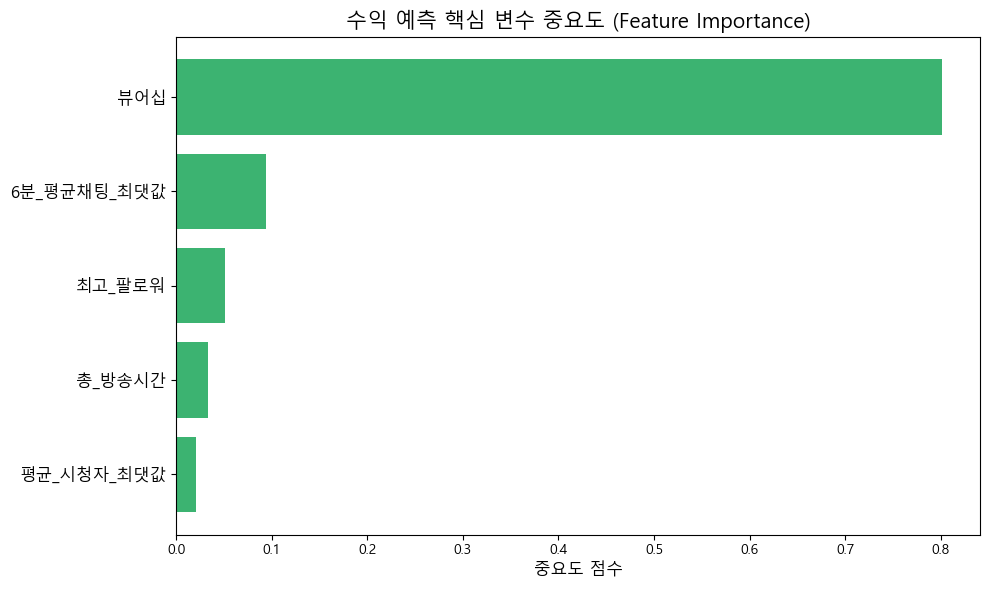

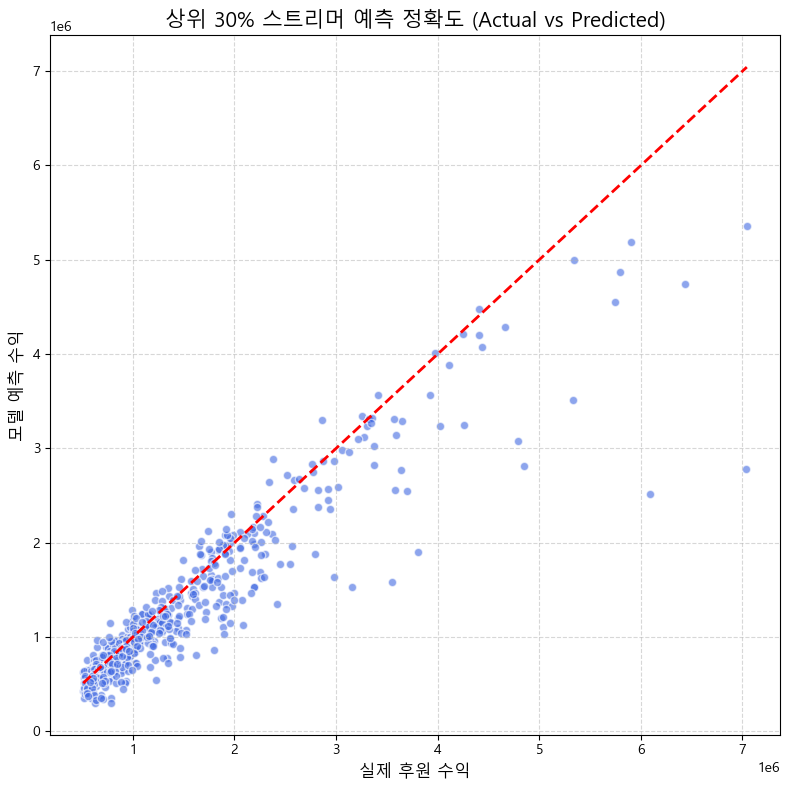

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import matplotlib.font_manager as fm

# 1. 한글 깨짐 방지 설정 (윈도우 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 및 학습 준비
df = pd.read_csv('final_softcone_streamers_V11_2.csv')

# SOOP 데이터 중 수익이 있는 데이터로 모델 학습 (인사이트 도출용)
train_df = df[(df['플랫폼'] == 'SOOP') & (df['도네이션'] > 0)].copy()
features = ['뷰어십', '최고_팔로워', '총_방송시간', '6분_평균채팅_최댓값', '평균_시청자_최댓값']
X = train_df[features]
y = train_df['도네이션']
y_log = np.log1p(y)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y_log)

# ---------------------------------------------------------
# 시각화 2: 피쳐 중요도 (수익의 핵심 동인 증명)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
importances = model.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='mediumseagreen')
plt.yticks(range(len(indices)), [features[i] for i in indices], fontsize=12)
plt.title('수익 예측 핵심 변수 중요도 (Feature Importance)', fontsize=15)
plt.xlabel('중요도 점수', fontsize=12)
plt.tight_layout()
plt.savefig('visual_2_feature_importance.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# 시각화 3: 실제값 vs 예측값 (모델 신뢰도 증명)
# ---------------------------------------------------------
y_pred = np.expm1(model.predict(X))
threshold = np.percentile(y, 70) # 상위 30%
upper_mask = y >= threshold

plt.figure(figsize=(8, 8))
plt.scatter(y[upper_mask], y_pred[upper_mask], alpha=0.6, color='royalblue', edgecolors='white')
plt.plot([y[upper_mask].min(), y[upper_mask].max()], 
         [y[upper_mask].min(), y[upper_mask].max()], 'r--', lw=2)
plt.title('상위 30% 스트리머 예측 정확도 (Actual vs Predicted)', fontsize=15)
plt.xlabel('실제 후원 수익', fontsize=12)
plt.ylabel('모델 예측 수익', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('visual_3_accuracy_check.png', dpi=300)
plt.show()

세그먼트 - 성단

In [25]:
import pandas as pd

# 1. 메인 DB (원본 데이터) 불러오기
df_main = pd.read_csv('final_softcone_for_team.csv', encoding='utf-8-sig')

# 2. '소속'이 없는 개인세(솔로) 스트리머들은 분석 대상이 아니니 제외
df_main = df_main.dropna(subset=['소속'])

# 3. 그룹화 규칙 딕셔너리 
# (원본 컬럼명에 맞춰서 매칭했습니다)
agg_rules = {
    '스트리머명': 'count',           # 멤버수 구하기 용도
    '최고_팔로워': 'sum',            # 합계
    '6분_최고채팅': 'max',            # 최댓값
    '6분_평균채팅_최댓값': 'mean',     # 평균 (원본 컬럼명 '6분_평균채팅_최댓값')
    '최고_시청자': 'max',            # 최댓값
    '평균_시청자_최댓값': 'max',      # 최댓값 (원본 컬럼명 매칭)
    '뷰어십': 'sum',               # 합계
    '도네이션': 'sum',              # 합계
    'X_팔로워': 'sum',              # 합계
    '유튜브_구독자': 'sum',           # 합계
    '팬카페_가입자': 'max'            # 최댓값
}

# 4. 소속을 기준으로 그룹화(groupby) 
grouped_df = df_main.groupby('소속').agg(agg_rules).reset_index()

# 5. 컬럼 이름 변경 
grouped_df.rename(columns={
    '스트리머명': '멤버수',
    '최고_팔로워': '합계_최고팔로워',
    '6분_최고채팅': '최댓값_6분최고채팅',
    '6분_평균채팅_최댓값': '평균_6분평균채팅',
    '최고_시청자': '최댓값_최고시청자',
    '평균_시청자_최댓값': '최댓값_평균시청자',
    '뷰어십': '합계_뷰어십',
    '도네이션': '합계_도네이션',
    'X_팔로워': '합계_X팔로워',
    '유튜브_구독자': '합계_유튜브구독자',
    '팬카페_가입자': '최댓값_팬카페가입자'
}, inplace=True)

# 6. 그룹화된 데이터 확인하기
print("1단계 완료: 그룹화된 메인 DB (Top 5 미리보기) ")
print(grouped_df.head())


1단계 완료: 그룹화된 메인 DB (Top 5 미리보기) 
       소속  멤버수  합계_최고팔로워  최댓값_6분최고채팅   평균_6분평균채팅  최댓값_최고시청자  최댓값_평균시청자  \
0     ㅇㄴㅇ    3      5167         773  226.333333        820        341   
1     걸즈원    8     13451        1715  112.500000       3285        275   
2   그림토피아    3      3210         469  109.000000        244        146   
3  그림프로덕션    8     49559        2375  642.750000       2921        968   
4    나름아이    5      2822         291   79.600000         90         46   

    합계_뷰어십  합계_도네이션  합계_X팔로워  합계_유튜브구독자  최댓값_팬카페가입자  
0   132269   768825       95        525         205  
1   210459  1749081     1228     117602         110  
2    85118   912527    12742       1578        1405  
3  1216335  9006486     4367      38950        2766  
4    12680   245825     2192       1939         218  


In [26]:
import pandas as pd

# 1. 메인 DB (원본 데이터) 불러오기
df_main = pd.read_csv('final_softcone_for_team.csv', encoding='utf-8-sig')

# 2. '소속'이 없는 데이터(솔로) 제외
df_main = df_main.dropna(subset=['소속'])

#  3. 블랙리스트 적용하여 쳐내기! 
black_list = ['왁타버스', '스코시즘', '하나비', '회사계정', '졸업']
df_main = df_main[~df_main['소속'].isin(black_list)]

# 4. 그룹화 규칙 딕셔너리
agg_rules = {
    '스트리머명': 'count',           # 멤버수 구하기 용도
    '최고_팔로워': 'sum',            # 합계
    '6분_최고채팅': 'max',            # 최댓값
    '6분_평균채팅_최댓값': 'mean',     # 평균
    '최고_시청자': 'max',            # 최댓값
    '평균_시청자_최댓값': 'max',      # 최댓값
    '뷰어십': 'sum',               # 합계
    '도네이션': 'sum',              # 합계
    'X_팔로워': 'sum',              # 합계
    '유튜브_구독자': 'sum',           # 합계
    '팬카페_가입자': 'max'            # 최댓값
}

# 5. 소속을 기준으로 그룹화(groupby)
grouped_df = df_main.groupby('소속').agg(agg_rules).reset_index()

# 6. 보기 좋게 컬럼 이름 변경
grouped_df.rename(columns={
    '스트리머명': '멤버수',
    '최고_팔로워': '합계_최고팔로워',
    '6분_최고채팅': '최댓값_6분최고채팅',
    '6분_평균채팅_최댓값': '평균_6분평균채팅',
    '최고_시청자': '최댓값_최고시청자',
    '평균_시청자_최댓값': '최댓값_평균시청자',
    '뷰어십': '합계_뷰어십',
    '도네이션': '합계_도네이션',
    'X_팔로워': '합계_X팔로워',
    '유튜브_구독자': '합계_유튜브구독자',
    '팬카페_가입자': '최댓값_팬카페가입자'
}, inplace=True)

#  7. 합계_뷰어십 기준으로 내림차순 정렬 
grouped_df = grouped_df.sort_values(by='합계_뷰어십', ascending=False).reset_index(drop=True)

# 8.  데이터 확인하기
print(" 1단계 완료: 불순물 제거 & 뷰어십 기준 정렬된 메인 DB (Top 5) ")
print(grouped_df[['소속', '합계_뷰어십', '멤버수', '합계_도네이션']].head())

 1단계 완료: 불순물 제거 & 뷰어십 기준 정렬된 메인 DB (Top 5) 
       소속    합계_뷰어십  멤버수   합계_도네이션
0   스텔라이브  84197251   11  67673564
1  이세계아이돌  39714400    6  25347961
2     에스더  19193308    4  19470592
3  프로젝트아이  17732569   12  35258990
4     하데스   6123607    4  12431906


In [27]:
import numpy as np

# 아까 만든 grouped_df에 이어서 작업합니다

# --------------------------------------------------------
# 1. 고도화 1: ARPU 100점 만점
# --------------------------------------------------------
# 원본 ARPU 계산 (분모가 0이 되는 걸 방지하기 위해 +1)
grouped_df['ARPU_원본'] = grouped_df['합계_도네이션'] / (grouped_df['합계_뷰어십'] + 1)

# 로그 씌우기 (격차 압축)
grouped_df['ARPU_log'] = np.log1p(grouped_df['ARPU_원본'])

# Min-Max 스케일링 (0~100점)
min_arpu = grouped_df['ARPU_log'].min()
max_arpu = grouped_df['ARPU_log'].max()
grouped_df['ARPU_점수'] = ((grouped_df['ARPU_log'] - min_arpu) / (max_arpu - min_arpu)) * 100


# --------------------------------------------------------
# 2. 고도화 2: 플랫폼 체급 스코어 100점 만점
# --------------------------------------------------------
# 내부 지표로 쓸 컬럼들 모음
internal_cols = [
    '합계_뷰어십', '합계_도네이션', '최댓값_최고시청자', 
    '최댓값_평균시청자', '합계_최고팔로워', '최댓값_6분최고채팅', '평균_6분평균채팅'
]

grouped_df['플랫폼_체급_Z합산'] = 0

for col in internal_cols:
    # 1) 로그 변환
    log_s = np.log1p(grouped_df[col])
    # 2) Z-Score (표준화): (내 점수 - 평균) / 표준편차
    z_s = (log_s - log_s.mean()) / log_s.std()
    # 3) Z값 합산 (모든 지표가 공평하게 더해짐)
    grouped_df['플랫폼_체급_Z합산'] += z_s

# Min-Max 스케일링 (0~100점) 
min_plat = grouped_df['플랫폼_체급_Z합산'].min()
max_plat = grouped_df['플랫폼_체급_Z합산'].max()
grouped_df['플랫폼체급_점수'] = ((grouped_df['플랫폼_체급_Z합산'] - min_plat) / (max_plat - min_plat)) * 100


# --------------------------------------------------------
# 3. 고도화 3: 외부 인기 점수 (외부 지표) 100점 만점
# --------------------------------------------------------
# 외부 지표로 쓸 컬럼들 모음
external_cols = ['합계_X팔로워', '합계_유튜브구독자', '최댓값_팬카페가입자']

grouped_df['외부인기_Z합산'] = 0

for col in external_cols:
    log_s = np.log1p(grouped_df[col])
    z_s = (log_s - log_s.mean()) / log_s.std()
    grouped_df['외부인기_Z합산'] += z_s

# Min-Max 스케일링 (0~100점)
min_ext = grouped_df['외부인기_Z합산'].min()
max_ext = grouped_df['외부인기_Z합산'].max()
grouped_df['외부인기_점수'] = ((grouped_df['외부인기_Z합산'] - min_ext) / (max_ext - min_ext)) * 100


# --------------------------------------------------------
# 결과 확인 및 반올림 처리
# --------------------------------------------------------
# 보기 좋게 소수점 둘째 자리까지만 남기기
check_cols = ['소속', 'ARPU_점수', '플랫폼체급_점수', '외부인기_점수']
grouped_df[check_cols] = grouped_df[check_cols].round(2)

print(" 2단계 완료: 고도화된 메인 지표 ")
print(grouped_df.sort_values(by='플랫폼체급_점수', ascending=False)[check_cols].head(10))

 2단계 완료: 고도화된 메인 지표 
        소속  ARPU_점수  플랫폼체급_점수  외부인기_점수
1   이세계아이돌     0.00    100.00    76.61
0    스텔라이브     3.03     95.96   100.00
2      에스더     6.50     86.50    78.39
5     블루점프    14.31     85.81    63.28
3   프로젝트아이    18.92     84.79    84.73
4      하데스    19.35     82.69    60.42
10    싸이코드    28.28     79.46    87.56
7      이브닛    19.94     79.05    71.69
6     오버더월    30.23     76.50    78.33
8      도파민    41.65     75.98    53.91


In [28]:
import numpy as np

# --------------------------------------------------------
# 1. 고도화 1: ARPU 100점 만점
# --------------------------------------------------------
grouped_df['ARPU_원본'] = grouped_df['합계_도네이션'] / (grouped_df['합계_뷰어십'])
grouped_df['ARPU_log'] = np.log1p(grouped_df['ARPU_원본'])

min_arpu = grouped_df['ARPU_log'].min()
max_arpu = grouped_df['ARPU_log'].max()
grouped_df['ARPU_점수'] = ((grouped_df['ARPU_log'] - min_arpu) / (max_arpu - min_arpu)) * 100


# --------------------------------------------------------
# 2. 고도화 2: 플랫폼 체급 스코어 (내부 지표) 100점 만점
# --------------------------------------------------------
internal_cols = [
    '합계_뷰어십', '합계_도네이션', '최댓값_최고시청자', 
    '최댓값_평균시청자', '합계_최고팔로워', '최댓값_6분최고채팅', '평균_6분평균채팅'
]

grouped_df['플랫폼_체급_Z합산'] = 0

for col in internal_cols:
    log_s = np.log1p(grouped_df[col])
    z_s = (log_s - log_s.mean()) / log_s.std()
    grouped_df['플랫폼_체급_Z합산'] += z_s

min_plat = grouped_df['플랫폼_체급_Z합산'].min()
max_plat = grouped_df['플랫폼_체급_Z합산'].max()
grouped_df['플랫폼체급_점수'] = ((grouped_df['플랫폼_체급_Z합산'] - min_plat) / (max_plat - min_plat)) * 100


# --------------------------------------------------------
# 3. 고도화 3: 외부 인기 점수 (외부 지표) 100점 만점
# --------------------------------------------------------
external_cols = ['합계_X팔로워', '합계_유튜브구독자', '최댓값_팬카페가입자']

grouped_df['외부인기_Z합산'] = 0

for col in external_cols:
    log_s = np.log1p(grouped_df[col])
    z_s = (log_s - log_s.mean()) / log_s.std()
    grouped_df['외부인기_Z합산'] += z_s

min_ext = grouped_df['외부인기_Z합산'].min()
max_ext = grouped_df['외부인기_Z합산'].max()
grouped_df['외부인기_점수'] = ((grouped_df['외부인기_Z합산'] - min_ext) / (max_ext - min_ext)) * 100


# --------------------------------------------------------
#  결과 확인: 정수형으로 변환
# --------------------------------------------------------
check_cols = ['ARPU_점수', '플랫폼체급_점수', '외부인기_점수']

grouped_df[check_cols] = grouped_df[check_cols].round(0).astype(int)

print(" 2단계 완료: 고도화된 메인 지표 ")
print(grouped_df[['소속'] + check_cols].sort_values(by='플랫폼체급_점수', ascending=False).head(10))

 2단계 완료: 고도화된 메인 지표 
        소속  ARPU_점수  플랫폼체급_점수  외부인기_점수
1   이세계아이돌        0       100       77
0    스텔라이브        3        96      100
2      에스더        7        86       78
5     블루점프       14        86       63
3   프로젝트아이       19        85       85
4      하데스       19        83       60
7      이브닛       20        79       72
10    싸이코드       28        79       88
6     오버더월       30        77       78
8      도파민       42        76       54


In [29]:
import numpy as np

# --------------------------------------------------------
# 1. 파생지표 고도화: 가성비 대중성 (100점 만점)
# --------------------------------------------------------
# 공식: 외부인기 점수 / log(합계 뷰어십)
# 뷰어십(체급) 대비 외부 인지도가 얼마나 기형적으로 높은가
grouped_df['가성비대중성_원본'] = grouped_df['외부인기_점수'] / np.log1p(grouped_df['합계_뷰어십'])

# Min-Max 스케일링 (0~100점)
min_pop = grouped_df['가성비대중성_원본'].min()
max_pop = grouped_df['가성비대중성_원본'].max()
grouped_df['대중성_점수'] = ((grouped_df['가성비대중성_원본'] - min_pop) / (max_pop - min_pop)) * 100


# --------------------------------------------------------
# 2. 궁극의 지표 고도화: 최종 영입 우선점수 (100점 만점)
# --------------------------------------------------------
# 3대 핵심 점수 합산
#  3개의 순도 100% 점수를 더합니다.
grouped_df['영입우선_원본'] = grouped_df['플랫폼체급_점수'] + grouped_df['ARPU_점수'] + grouped_df['대중성_점수']

# 대망의 최종 100점 만점 스케일링
min_prio = grouped_df['영입우선_원본'].min()
max_prio = grouped_df['영입우선_원본'].max()
grouped_df['영입우선_점수'] = ((grouped_df['영입우선_원본'] - min_prio) / (max_prio - min_prio)) * 100


# --------------------------------------------------------
#  소수점 제거 및 최종 결과 출력 
# --------------------------------------------------------
final_cols = ['대중성_점수', '영입우선_점수']

# 깔끔하게 반올림 후 정수(int) 처리
grouped_df[final_cols] = grouped_df[final_cols].round(0).astype(int)

# 보기 좋게 컬럼 순서 정리
show_cols = ['소속', '멤버수', '합계_뷰어십', '플랫폼체급_점수', 'ARPU_점수', '대중성_점수', '영입우선_점수']

print("100점 만점 기반 최종 영입 우선순위 TOP 15 ")
# 최종 점수 높은 순으로 15팀 출력
print(grouped_df.sort_values(by='영입우선_점수', ascending=False)[show_cols].head(22))

100점 만점 기반 최종 영입 우선순위 TOP 15 
         소속  멤버수   합계_뷰어십  플랫폼체급_점수  ARPU_점수  대중성_점수  영입우선_점수
26      크로아    5   592857        68       59      98      100
86      셀리브    6    38574        52       64      93       90
20    리레볼루션    4   924754        69       44      96       90
50    이소로피아    3   189774        54       72      83       90
102     트윌릿    1    17355        41       91      78       90
28    브이레코드   11   439737        59       69      79       89
77     바라바라    6    56549        51       66      90       88
107    브이레이    2    12277        31       85      89       87
87    오토메테일    4    35465        43       81      80       87
60      크레슈    4   136602        53       81      70       86
76     스테이브    4    56842        49       75      80       86
101    이엔아이    4    18083        37       77      87       85
10     싸이코드    5  2629047        79       28      94       85
24    몽상컴퍼니    7   789706        67       63      70       84
65     에이더스    4    97381        48     

크로아 - x
바라바라 - 완전체
리레볼루션 - 완전체
이소로피아 - 완전체
셀리브 - 완전체
트윌릿 - x
브이레코드 - x
브이레이 - x
오테메테일 - 완전체
크레슈 - 완전체
스테이브 - 완전체
이엔아이 - 완전체
싸이코드 - 완전체
몽상컴퍼니 - 완전체
에이더스 - 완전체 
루미니아 - 완전체
리베르타 - 완전체 
에델리안 - 완전체
브이레이어 - x 
모아이대학교 - x
리액트케이알 - 완전체
크로아, 트윌릿, 브이레코드, 브이레이, 브이레이어, 모아이대학교 

In [30]:
import pandas as pd

# 1. 메인 DB (원본 데이터) 불러오기
df_main = pd.read_csv('final_softcone_for_team.csv', encoding='utf-8-sig')

# 2. '소속'이 없는 데이터(솔로) 제외
df_main = df_main.dropna(subset=['소속'])

#  3. [화이트리스트 필터]  최종 15팀만 남기기 
target_list = [
    '바라바라', '리레볼루션', '이소로피아', '셀리브', '오토메테일', 
    '크레슈', '스테이브', '이엔아이', '싸이코드', '몽상컴퍼니', 
    '에이더스', '루미니아', '리베르타', '에델리안', '리액트케이알'
]

df_main = df_main[df_main['소속'].isin(target_list)]


# 4. 그룹화 규칙 딕셔너리
agg_rules = {
    '스트리머명': 'count',           
    '최고_팔로워': 'sum',            
    '6분_최고채팅': 'max',            
    '6분_평균채팅_최댓값': 'mean',     
    '최고_시청자': 'max',            
    '평균_시청자_최댓값': 'max',      
    '뷰어십': 'sum',               
    '도네이션': 'sum',              
    'X_팔로워': 'sum',              
    '유튜브_구독자': 'sum',           
    '팬카페_가입자': 'max'            
}

# 5. 소속을 기준으로 그룹화(groupby)
grouped_df = df_main.groupby('소속').agg(agg_rules).reset_index()

# 6. 보기 좋게 컬럼 이름 깔끔하게 변경
grouped_df.rename(columns={
    '스트리머명': '멤버수',
    '최고_팔로워': '합계_최고팔로워',
    '6분_최고채팅': '최댓값_6분최고채팅',
    '6분_평균채팅_최댓값': '평균_6분평균채팅',
    '최고_시청자': '최댓값_최고시청자',
    '평균_시청자_최댓값': '최댓값_평균시청자',
    '뷰어십': '합계_뷰어십',
    '도네이션': '합계_도네이션',
    'X_팔로워': '합계_X팔로워',
    '유튜브_구독자': '합계_유튜브구독자',
    '팬카페_가입자': '최댓값_팬카페가입자'
}, inplace=True)

# 7. 합계_뷰어십 기준으로 내림차순 정렬
grouped_df = grouped_df.sort_values(by='합계_뷰어십', ascending=False).reset_index(drop=True)

# 8. 결과 확인
print(" 15팀 그룹화 완료")
print(grouped_df[['소속', '합계_뷰어십', '멤버수', '합계_도네이션']])

 15팀 그룹화 완료
        소속   합계_뷰어십  멤버수  합계_도네이션
0     싸이코드  2629047    5  7951943
1   리액트케이알  1178519    7  8494253
2    리레볼루션   924754    4  5254413
3    몽상컴퍼니   789706    7  8703730
4     리베르타   384599    3  3718488
5    이소로피아   189774    3  2852993
6      크레슈   136602    4  2787678
7     에이더스    97381    4  1155328
8     스테이브    56842    4   949190
9     바라바라    56549    6   709730
10    루미니아    52288    3  1166980
11    에델리안    41292    6   799450
12     셀리브    38574    6   437206
13   오토메테일    35465    4   727658
14    이엔아이    18083    4   325094


In [31]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 전체 생태계 기준 그룹화 (블랙리스트만 제외)
# ==========================================
df_main = pd.read_csv('final_softcone_for_team.csv', encoding='utf-8-sig')
df_main = df_main.dropna(subset=['소속'])

# 1, 2차 블랙리스트 걷어내기
black_list = [
    '왁타버스', '스코시즘', '하나비', '회사계정', '졸업',
    '크로아', '트윌릿', '브이레코드', '브이레이', '브이레이어', '모아이대학교'
]
df_main = df_main[~df_main['소속'].isin(black_list)]

#  결측치 0으로 채우기 (전체 데이터 연산 시 에러 방지)
num_cols = ['최고_팔로워', '6분_최고채팅', '6분_평균채팅_최댓값', '최고_시청자', '평균_시청자_최댓값', '뷰어십', '도네이션', 'X_팔로워', '유튜브_구독자', '팬카페_가입자']
df_main[num_cols] = df_main[num_cols].fillna(0)

agg_rules = {
    '스트리머명': 'count',           
    '최고_팔로워': 'sum',            
    '6분_최고채팅': 'max',            
    '6분_평균채팅_최댓값': 'mean',     
    '최고_시청자': 'max',            
    '평균_시청자_최댓값': 'max',      
    '뷰어십': 'sum',               
    '도네이션': 'sum',              
    'X_팔로워': 'sum',              
    '유튜브_구독자': 'sum',           
    '팬카페_가입자': 'max'            
}

grouped_df = df_main.groupby('소속').agg(agg_rules).reset_index()

grouped_df.rename(columns={
    '스트리머명': '멤버수', '최고_팔로워': '합계_최고팔로워', '6분_최고채팅': '최댓값_6분최고채팅',
    '6분_평균채팅_최댓값': '평균_6분평균채팅', '최고_시청자': '최댓값_최고시청자', '평균_시청자_최댓값': '최댓값_평균시청자',
    '뷰어십': '합계_뷰어십', '도네이션': '합계_도네이션', 'X_팔로워': '합계_X팔로워',
    '유튜브_구독자': '합계_유튜브구독자', '팬카페_가입자': '최댓값_팬카페가입자'
}, inplace=True)

# ==========================================
# 2. 전체 생태계 기준으로 점수 계산
# ==========================================
# [ARPU]  전체 데이터 중 뷰어십 0인 크루 때문에 터지는 것 방지
safe_viewership = grouped_df['합계_뷰어십'].replace(0, 1)
grouped_df['ARPU_원본'] = grouped_df['합계_도네이션'] / safe_viewership
grouped_df['ARPU_log'] = np.log1p(grouped_df['ARPU_원본'])
min_arpu, max_arpu = grouped_df['ARPU_log'].min(), grouped_df['ARPU_log'].max()
grouped_df['ARPU_점수'] = ((grouped_df['ARPU_log'] - min_arpu) / (max_arpu - min_arpu)) * 100

# [플랫폼 체급]
internal_cols = ['합계_뷰어십', '합계_도네이션', '최댓값_최고시청자', '최댓값_평균시청자', '합계_최고팔로워', '최댓값_6분최고채팅', '평균_6분평균채팅']
grouped_df['플랫폼_체급_Z합산'] = 0
for col in internal_cols:
    log_s = np.log1p(grouped_df[col])
    if log_s.std() != 0:
        grouped_df['플랫폼_체급_Z합산'] += (log_s - log_s.mean()) / log_s.std()
min_plat, max_plat = grouped_df['플랫폼_체급_Z합산'].min(), grouped_df['플랫폼_체급_Z합산'].max()
grouped_df['플랫폼체급_점수'] = ((grouped_df['플랫폼_체급_Z합산'] - min_plat) / (max_plat - min_plat)) * 100

# [외부 인기]
external_cols = ['합계_X팔로워', '합계_유튜브구독자', '최댓값_팬카페가입자']
grouped_df['외부인기_Z합산'] = 0
for col in external_cols:
    log_s = np.log1p(grouped_df[col])
    if log_s.std() != 0:
        grouped_df['외부인기_Z합산'] += (log_s - log_s.mean()) / log_s.std()
min_ext, max_ext = grouped_df['외부인기_Z합산'].min(), grouped_df['외부인기_Z합산'].max()
grouped_df['외부인기_점수'] = ((grouped_df['외부인기_Z합산'] - min_ext) / (max_ext - min_ext)) * 100

# [가성비 대중성] 뷰어십 로그값이 0이 되어 무한대(inf)로 터지는 현상 차단
denom = np.log1p(grouped_df['합계_뷰어십'])
denom = np.where(denom == 0, 1, denom) 
grouped_df['가성비대중성_원본'] = grouped_df['외부인기_점수'] / denom

min_pop, max_pop = grouped_df['가성비대중성_원본'].min(), grouped_df['가성비대중성_원본'].max()
grouped_df['대중성_점수'] = ((grouped_df['가성비대중성_원본'] - min_pop) / (max_pop - min_pop)) * 100

# [최종 영입우선 점수]
grouped_df['영입우선_원본'] = grouped_df['플랫폼체급_점수'] + grouped_df['ARPU_점수'] + grouped_df['대중성_점수']
min_prio, max_prio = grouped_df['영입우선_원본'].min(), grouped_df['영입우선_원본'].max()
grouped_df['영입우선_점수'] = ((grouped_df['영입우선_원본'] - min_prio) / (max_prio - min_prio)) * 100

# 소수점 제거 (혹시 모를 찌꺼기 NaN까지 0으로 덮어버리기)
final_cols = ['플랫폼체급_점수', '외부인기_점수', 'ARPU_점수', '대중성_점수', '영입우선_점수']
grouped_df[final_cols] = grouped_df[final_cols].fillna(0).round(0).astype(int)

# ==========================================
#  3. 전체 성적표에서 15팀만 조회하기
# ==========================================
target_list = [
    '바라바라', '리레볼루션', '이소로피아', '셀리브', '오토메테일', 
    '크레슈', '스테이브', '이엔아이', '싸이코드', '몽상컴퍼니', 
    '에이더스', '루미니아', '리베르타', '에델리안', '리액트케이알'
]

# isin()으로 15팀만 쏙 빼서 새로운 변수에 담습니다
final_15_df = grouped_df[grouped_df['소속'].isin(target_list)].copy()

# 보기 좋게 컬럼 정리하고 영입우선_점수 순으로 정렬
show_cols = ['소속', '합계_뷰어십', '플랫폼체급_점수', 'ARPU_점수', '대중성_점수', '영입우선_점수']
final_result = final_15_df.sort_values(by='영입우선_점수', ascending=False)[show_cols].reset_index(drop=True)

print("15팀 최종 결승전 조회 완료! ")
print(final_result)

15팀 최종 결승전 조회 완료! 
        소속   합계_뷰어십  플랫폼체급_점수  ARPU_점수  대중성_점수  영입우선_점수
0    이소로피아   189774        54       72      84      100
1      셀리브    38574        52       64      93       99
2    리레볼루션   924754        69       44      96       99
3     바라바라    56549        51       66      90       98
4      크레슈   136602        53       81      71       96
5    오토메테일    35465        43       81      80       95
6     스테이브    56842        49       75      80       95
7     싸이코드  2629047        79       28      94       94
8     이엔아이    18083        37       77      88       94
9    몽상컴퍼니   789706        67       63      71       93
10    리베르타   384599        59       59      79       91
11    에이더스    97381        48       65      85       91
12    에델리안    41292        37       79      81       91
13    루미니아    52288        44       84      69       90
14  리액트케이알  1178519        69       51      72       87


In [32]:
#  타겟 15팀 리스트 (오토메테일 오타 수정 완료)
target_15 = [
    '바라바라', '리레볼루션', '이소로피아', '셀리브', '오토메테일', 
    '크레슈', '스테이브', '이엔아이', '싸이코드', '몽상컴퍼니', 
    '에이더스', '루미니아', '리베르타', '에델리안', '리액트케이알'
]

# 전체 데이터에서 15팀만  빼오기
final_plot_df = grouped_df[grouped_df['소속'].isin(target_15)].copy()

print(f"현재 시각화 대상: {len(final_plot_df)}개 팀")

현재 시각화 대상: 15개 팀
